In [29]:
from alerce.core import Alerce
from astropy.table import vstack, Table
import matplotlib.pyplot as plt
import pyvo as vo
import requests
import sqlalchemy as sa
import sys
import numpy as np
from astropy.coordinates import SkyCoord
from astropy import units as u
import re
import george
import scipy.optimize as op
import emcee
from matplotlib.backends.backend_pdf import PdfPages

In [3]:
alerce = Alerce()
alerce_tap = vo.dal.TAPService('https://tap.alerce.online/tap')

In [4]:
filename = "../Data/tns_II.csv"
sources = Table.read(filename, format="csv")
sources[0]

objid,name_prefix,name,ra,declination,redshift,typeid,type,reporting_groupid,reporting_group,source_groupid,source_group,discoverydate,discoverymag,discmagfilter,filter,reporters,time_received,internal_names,Discovery_ADS_bibcode,Class_ADS_bibcodes,creationdate,lastmodified
int64,str2,str8,float64,float64,float64,int64,str5,int64,str8,int64,str5,str23,float64,int64,str1,str454,str19,str97,str19,str187,str19,str19
205954,SN,2026ixo,224.991869263,9.56261970154,0.1225,10,SN II,74,ALeRCE,48,ZTF,2026-04-08 09:04:00.002,19.9935,110,g,"F. Forster, F.E. Bauer, G. Pignata, A. Munoz-Arancibia, S. Jurado, A. Mourao, A. Alvarez, F. Andrades, A. Bayo, G. Cabrera-Vives, M. Catelan, P.A. Estevez, S. Eyheramendy, B. Galindo, L. Hernandez-Garcia, H. Larranaga, K. Medina, D. Moreno-Cartagena, E. Munoz, I. Reyes, P. Sanchez-Saez, D. Rodriguez-Mancini, on behalf of the ALeRCE broker",2026-04-08 20:33:42,"ZTF26aaruydz, ATLAS26ebi, GOTO26dhb, PS26beq",2026TNSTR1481....1F,2026TNSCR2001....1S,2026-04-08 20:33:46,2026-05-10 12:38:05


In [5]:
ZTF_mask = sources["source_group"] == "ZTF"
ZTF = sources[ZTF_mask]
ZTF[0]

objid,name_prefix,name,ra,declination,redshift,typeid,type,reporting_groupid,reporting_group,source_groupid,source_group,discoverydate,discoverymag,discmagfilter,filter,reporters,time_received,internal_names,Discovery_ADS_bibcode,Class_ADS_bibcodes,creationdate,lastmodified
int64,str2,str8,float64,float64,float64,int64,str5,int64,str8,int64,str5,str23,float64,int64,str1,str454,str19,str97,str19,str187,str19,str19
205954,SN,2026ixo,224.991869263,9.56261970154,0.1225,10,SN II,74,ALeRCE,48,ZTF,2026-04-08 09:04:00.002,19.9935,110,g,"F. Forster, F.E. Bauer, G. Pignata, A. Munoz-Arancibia, S. Jurado, A. Mourao, A. Alvarez, F. Andrades, A. Bayo, G. Cabrera-Vives, M. Catelan, P.A. Estevez, S. Eyheramendy, B. Galindo, L. Hernandez-Garcia, H. Larranaga, K. Medina, D. Moreno-Cartagena, E. Munoz, I. Reyes, P. Sanchez-Saez, D. Rodriguez-Mancini, on behalf of the ALeRCE broker",2026-04-08 20:33:42,"ZTF26aaruydz, ATLAS26ebi, GOTO26dhb, PS26beq",2026TNSTR1481....1F,2026TNSCR2001....1S,2026-04-08 20:33:46,2026-05-10 12:38:05


In [6]:
#ZTF["internal_names"][0][:12]
ZTF_obj_II = []
pattern = r"ZTF"
for obj in ZTF["internal_names"]:
    #print(obj)
    if isinstance(obj, str):
        internal = obj.split(',')
        survay_name = [name for name in internal if re.search(pattern, name)]
        if survay_name:
            ZTF_obj_II.append(survay_name[0])

ZTF_obj_II = np.array(ZTF_obj_II)
print(len(ZTF_obj_II))

1325


In [7]:
light_curves = []
for obj in ZTF_obj_II[:20]:
    light = alerce.query_forced_photometry(obj, format="json")
    light_curves.append(light)

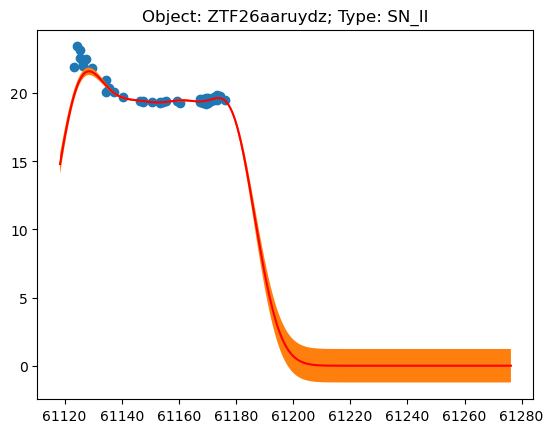

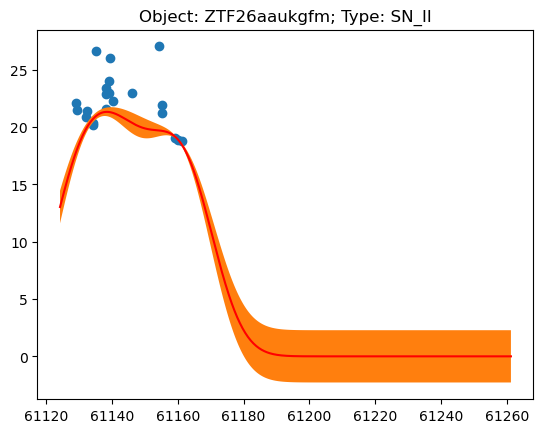

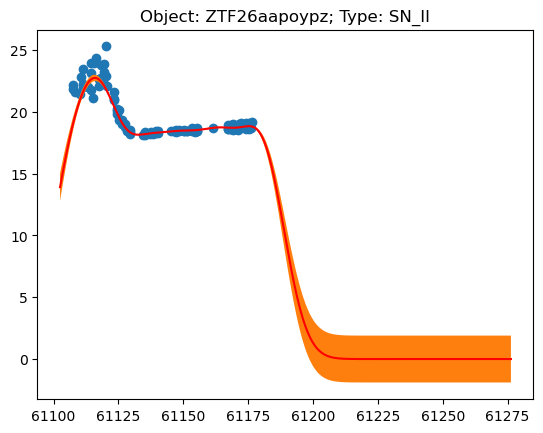

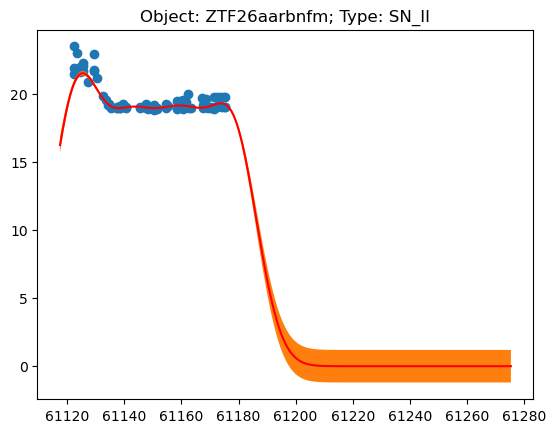

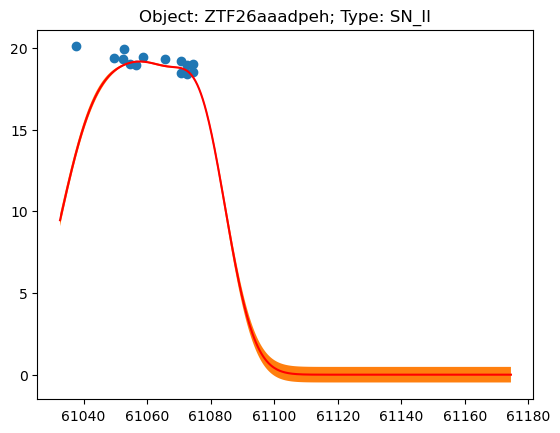

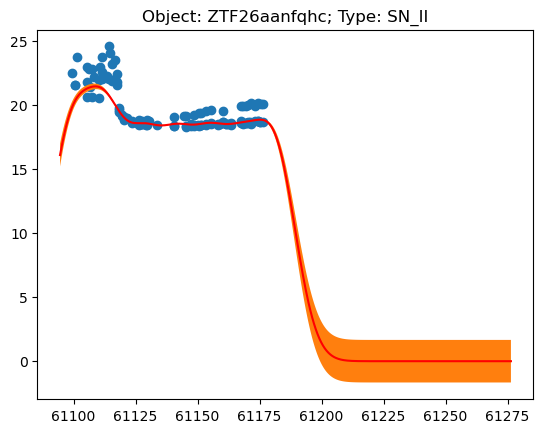

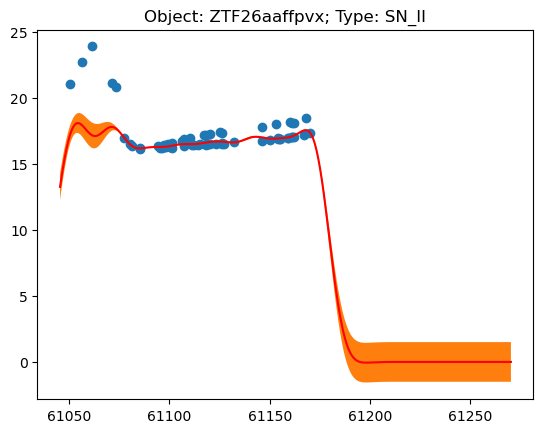

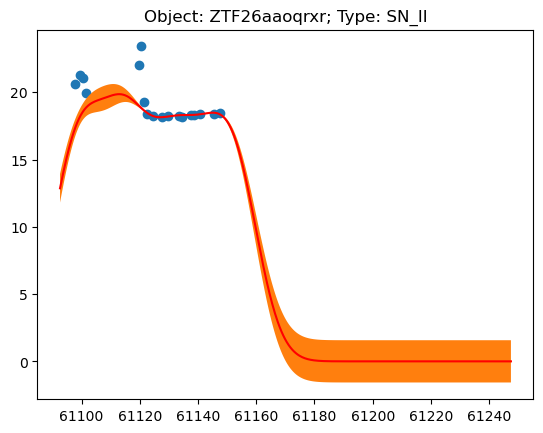

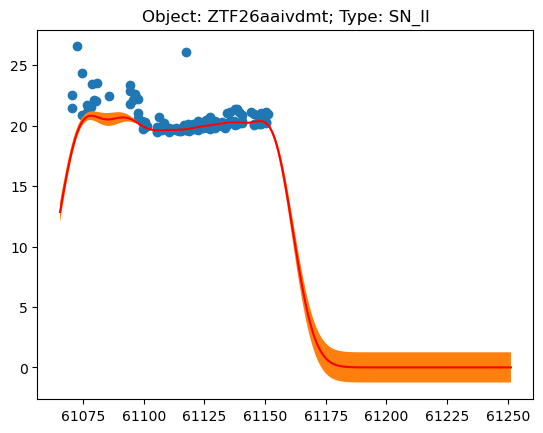

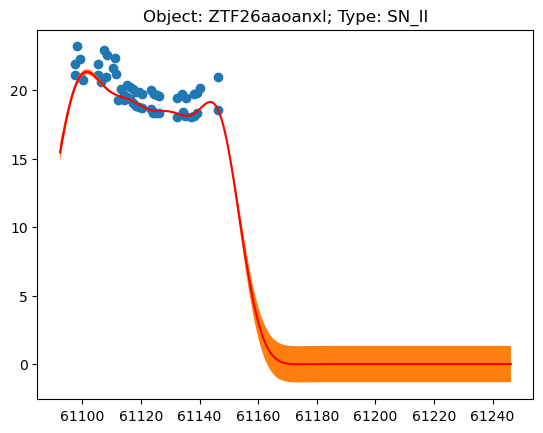

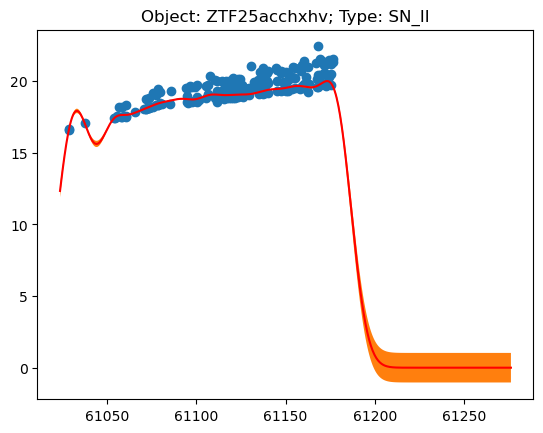

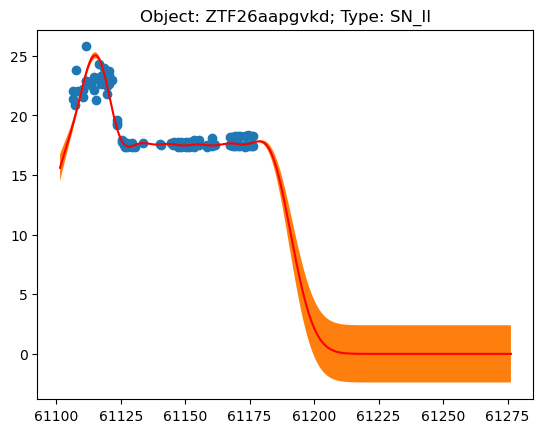

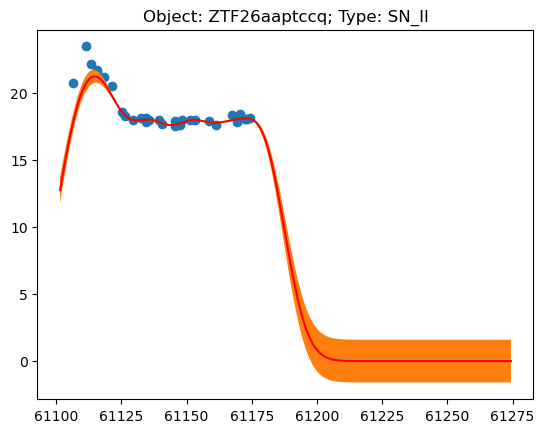

In [13]:
with PdfPages('./SN_II_plots.pdf') as pdf:
    for light in light_curves:
    
        if len(light) > 10:
    
            #initialize data
            time = [obs["mjd"] for obs in light]
            mag = [obs["mag"] for obs in light]
            error = [obs["e_mag"] for obs in light]
        
            #plot raw lightcurve
            plt.scatter(time, mag, marker='o')
        
            #initialize data range
            x_fit = np.linspace(np.min(time) - 5, np.max(time) + 100, 500)
        
            #get george off
            kernel =  np.var(mag) * george.kernels.ExpSquaredKernel(80)
            gp = george.GP(kernel)
            
            #use george
            gp.compute(time, error)
            pred, pred_var = gp.predict(mag, x_fit, return_var=True)
        
            #plot george
            plt.plot(x_fit, pred, color='r')
            error = np.pow(pred_var, 0.5)
        
            plt.fill_between(x_fit, pred - error, pred + error, interpolate=True)
            plt.title(f"Object: {light[0]["oid"]}; Type: SN_II")

            pdf.savefig()
            plt.show()
            plt.close()

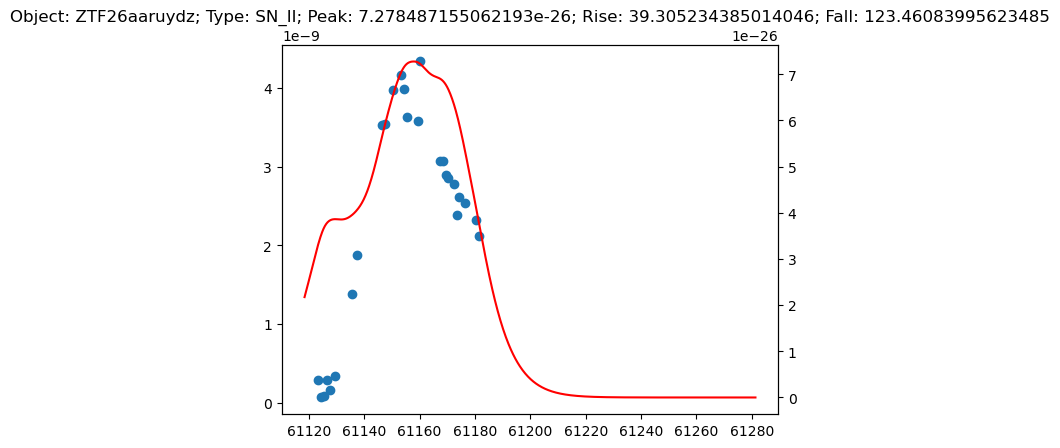

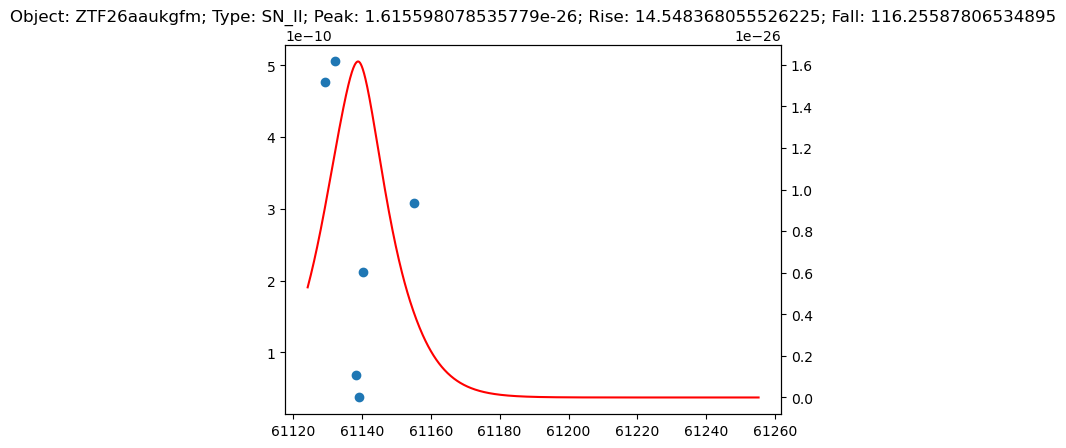

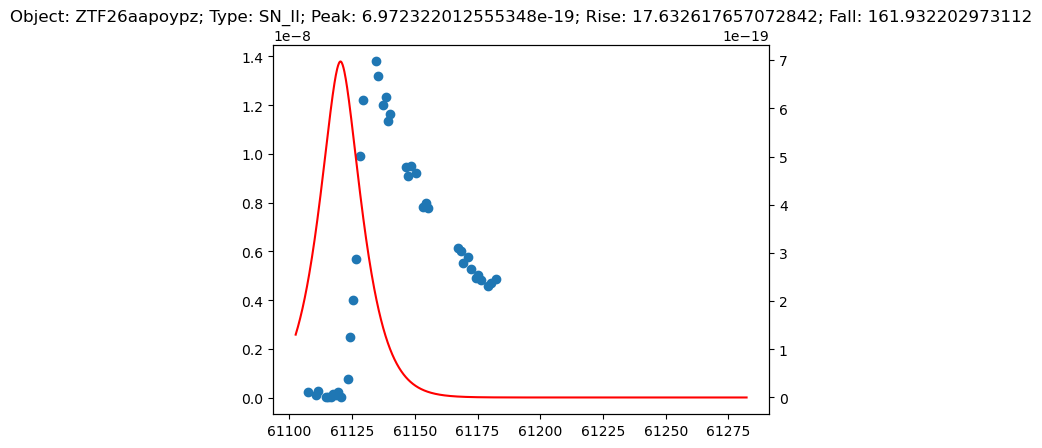

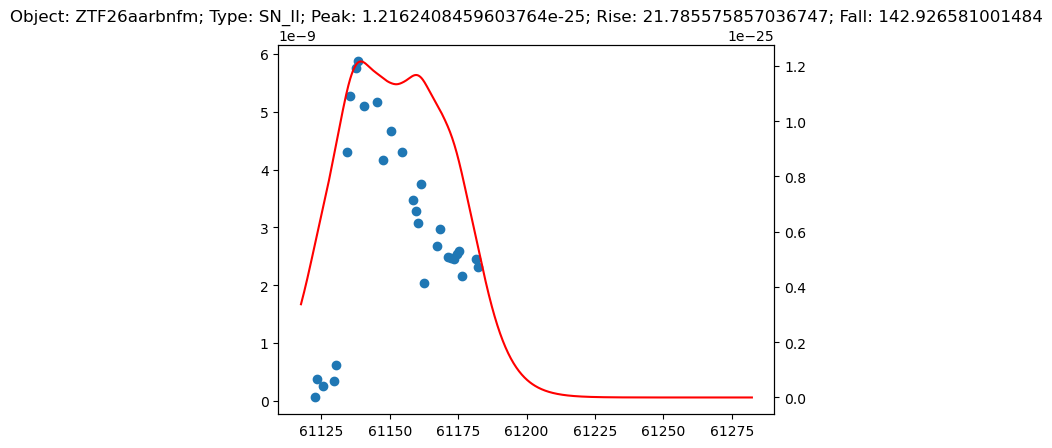

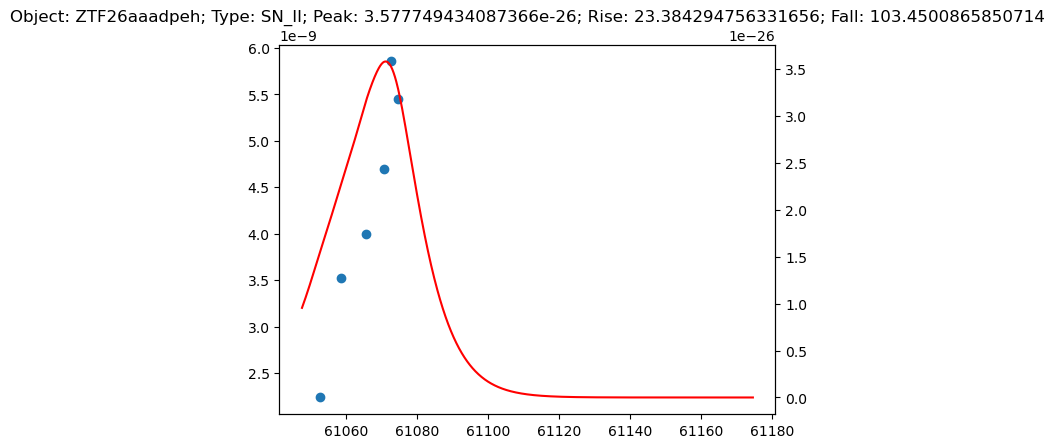

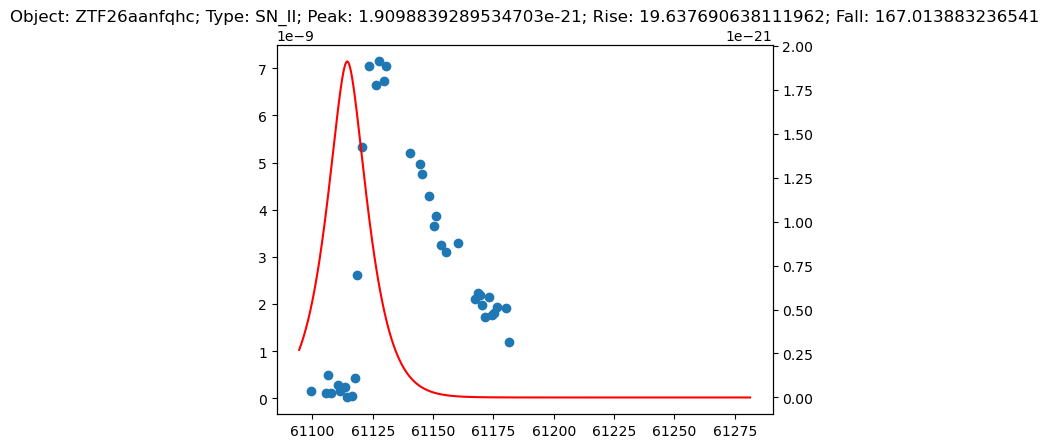

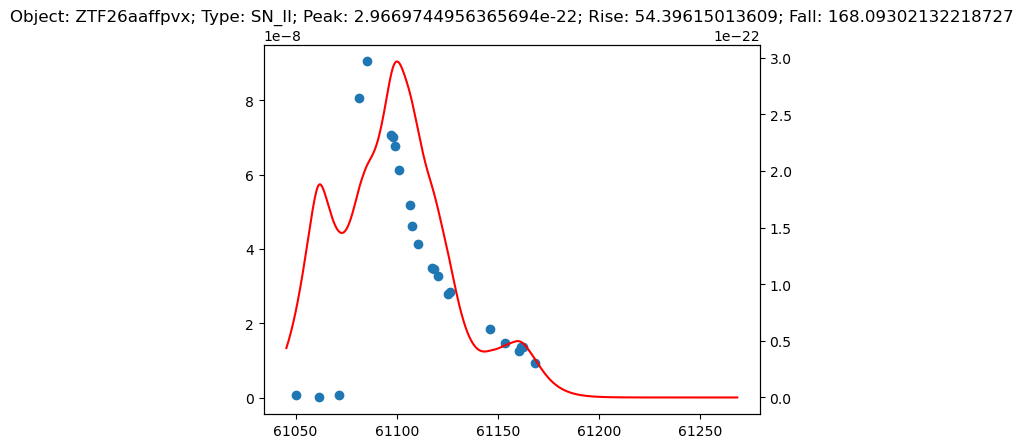

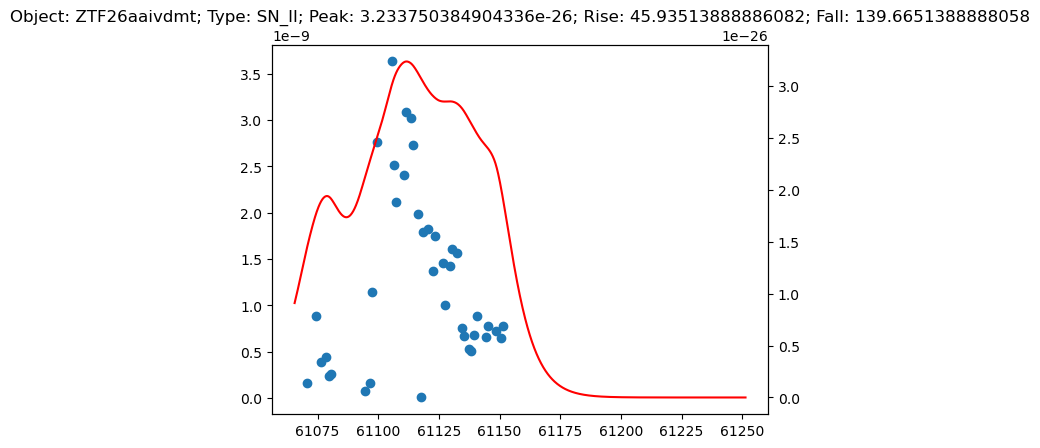

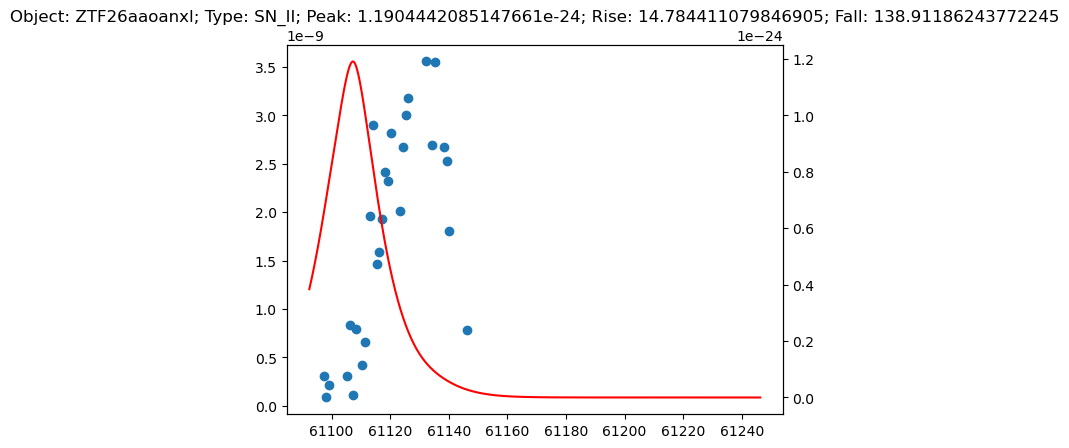

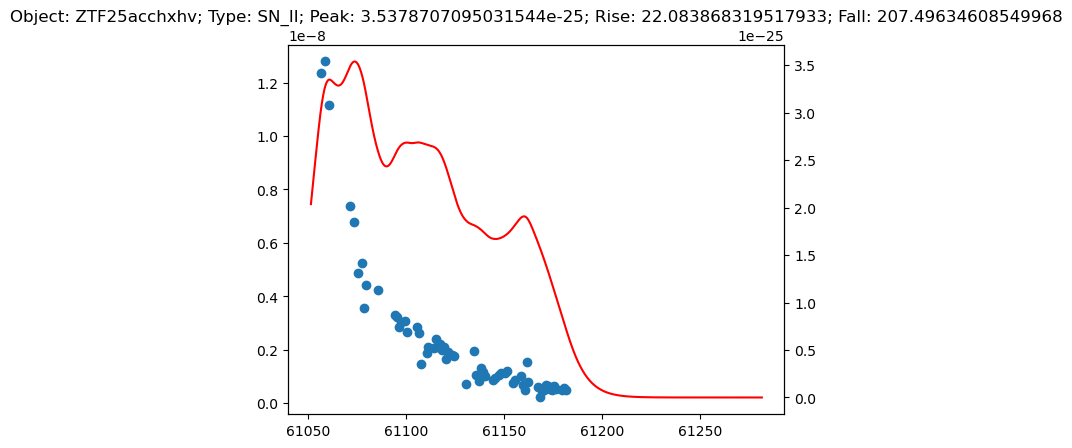

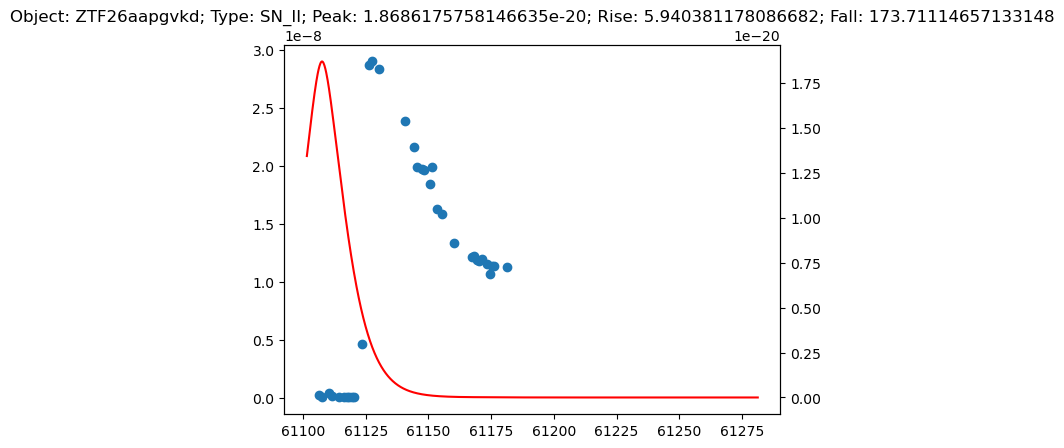

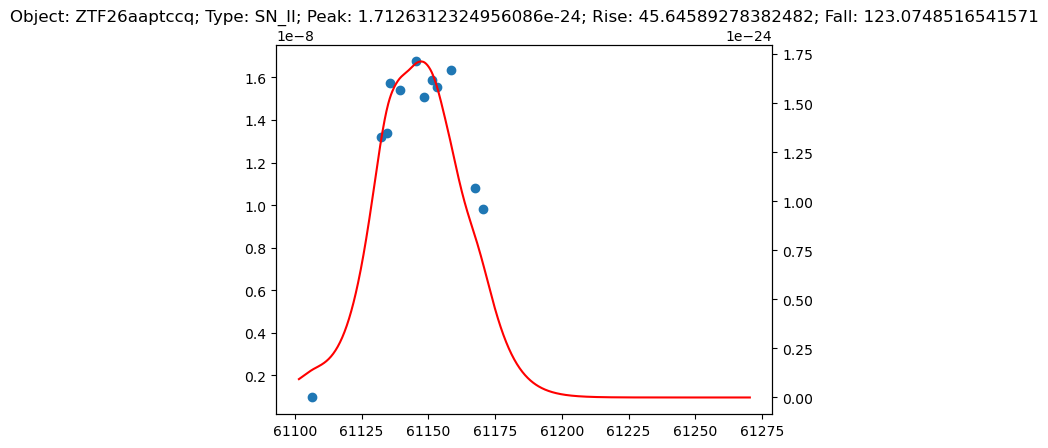

In [32]:
with PdfPages('./SN_II_plots.pdf') as pdf:
    dic_curves = []
    for light in light_curves:

        if len(light) > 10:

            time = []
            mag = []
            error = []
            #initialize data
            for obs in light:
                if obs["fid"] == 1:
                    if obs["mag"] > 15:
                        time.append(obs["mjd"])
                        mag.append(obs["mag"])
                        error.append(obs["e_mag"])

            #print(mag)
            mag = -1 * np.array(mag)
            mag_flipped = np.exp(mag)
            #print(mag_flipped)
            error = np.array(error)
            error = np.exp(-1 * error)

            if len(mag_flipped) > 0:
                    
                fig, ax1 = plt.subplots()
                
                #plot raw lightcurve
                ax1.scatter(time, mag_flipped, marker='o')
                #ax1.invert_yaxis()
            
                #initialize data range
                x_fit = np.linspace(np.min(time) - 5, np.max(time) + 100, 1000)
            
                #get george off
                #kernel =  np.var(mag_flipped) * george.kernels.ExpSquaredKernel(100)
                kernel = np.var(mag_flipped) * george.kernels.Matern32Kernel(metric=100)
                gp = george.GP(kernel, solver=george.HODLRSolver)

                #define george optimization
                def nll(p):
                    gp.set_parameter_vector(p)
                    ll = gp.log_likelihood(mag_flipped, quiet=True)
                    return -ll if np.isfinite(ll) else 1e25
                def grad_nll(p):
                    gp.set_parameter_vector(p)
                    return -gp.grad_log_likelihood(mag_flipped, quiet=True)

                #optimize george
                gp.compute(time, error)
                p0 = gp.get_parameter_vector()
                results = op.minimize(nll, p0, jac=grad_nll, method="L-BFGS-B")

                #update george
                gp.set_parameter_vector(results.x)
                
                #use george
                gp.compute(time, error)
                #print(mag_flipped.shape, x_fit.shape)
                pred, pred_var = gp.predict(mag_flipped, x_fit, return_var=True)
    
                #find rise time
                peak = np.max(pred)
                #print(peak)
                peak_index = np.argmax(pred)
                #print(peak_index)
                slopes = np.gradient(pred, x_fit)
                rise_days = 0
                for point in x_fit[:peak_index]:
                    if slopes[np.where(x_fit == point)] < 1:
                        rise_days = point
                rise_time = rise_days - x_fit[0]
    
                #find down time
                down_days = 0
                for point in x_fit[peak_index+1:]:
                    if (slopes[np.where(x_fit == point)] < 1):
                        down_days = point
                fall_time = down_days - x_fit[peak_index]
    
                #add curve to dictionary and append to list
                #print(table_curves)
                error = np.pow(pred_var, 0.5)
                dic = {"object": light[0]["oid"], "type": "SNII", "mjd": x_fit, "mag": pred, "error": error, "peak": peak, "rise": rise_time, "fall": fall_time}
                dic_curves.append(dic)
                #print(table_curves)
    
                ax2 = ax1.twinx()
    
                #plot george
                ax2.plot(x_fit, pred, color='r')
            
                #ax1.fill_between(x_fit, pred - error, pred + error, interpolate=True)
                plt.title(f"Object: {light[0]["oid"]}; Type: SN_II; Peak: {peak}; Rise: {rise_time}; Fall: {fall_time}")
    
                pdf.savefig()
                plt.show()
                plt.close()

table_curves = vstack(dic_curves)
table_curves.write('SNII_test.ecsv', format='ascii.ecsv', overwrite=True)